# 🛍 Mini Project — Customer Segmentation using Clustering

---

# 📌 Problem Statement

A shopping mall wants to understand its customers better.

Using customer information such as:

• Age  
• Annual Income  
• Spending Score  

The goal is to **segment customers into groups** so that marketing strategies can be customized.

---

# 🎯 Objective

Use **K-Means Clustering** to identify different types of customers.

This helps the business:

• Target high spending customers  
• Design personalized marketing campaigns  
• Improve customer experience

---

# 📂 Dataset Description

Dataset: **Mall Customers Dataset**

Features:

CustomerID  
Gender  
Age  
Annual Income (k$)  
Spending Score (1-100)

For clustering we will use:

• Annual Income  
• Spending Score

---

# 🧠 Machine Learning Workflow

1️⃣ Load dataset  
2️⃣ Select important features  
3️⃣ Apply Elbow Method  
4️⃣ Train K-Means model  
5️⃣ Visualize clusters  
6️⃣ Interpret results

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
x=df[['Annual Income (k$)','Spending Score (1-100)']]

#Elbow method

In [10]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
x_scaled=scalar.fit_transform(x)

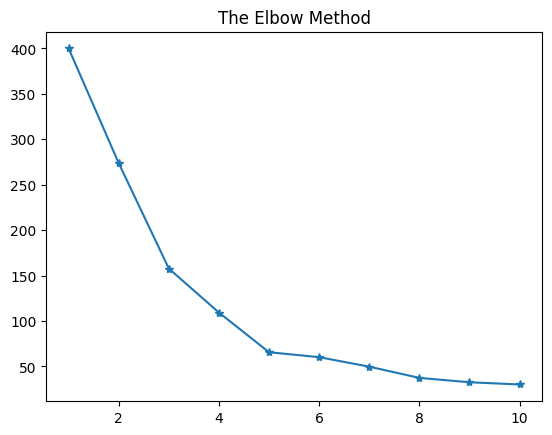

In [13]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans_model=KMeans(n_clusters=i,random_state=42)
    kmeans_model.fit(x_scaled)
    wcss.append(kmeans_model.inertia_)
plt.title("The Elbow Method")
plt.plot(range(1,11),wcss,marker='*')

In [23]:
from sklearn.cluster import KMeans
kmeans_model=KMeans(n_clusters=5,random_state=42)
df['KMeans_clusters']=kmeans_model.fit_predict(x_scaled)
df.head()



,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_clusters
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [26]:
df['KMeans_clusters']=df['KMeans_clusters']+1
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_clusters
0,1,Male,19,15,39,6
1,2,Male,21,15,81,4
2,3,Female,20,16,6,6
3,4,Female,23,16,77,4
4,5,Female,31,17,40,6


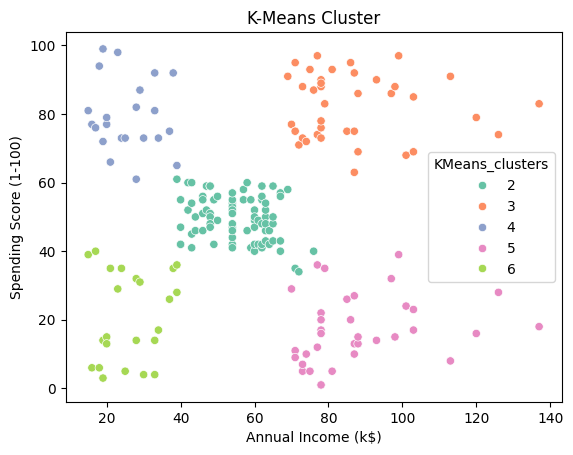

In [30]:
import seaborn as sns
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_clusters',palette='Set2', data=df)
plt.title('K-Means Cluster')
plt.show()

In [32]:
df.groupby('KMeans_clusters').mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
KMeans_clusters,,,,
2,86.320988,42.716049,55.296296,49.518519
3,162.000000,32.692308,86.538462,82.128205
4,23.090909,25.272727,25.727273,79.363636
5,164.371429,41.114286,88.200000,17.114286
6,23.000000,45.217391,26.304348,20.913043


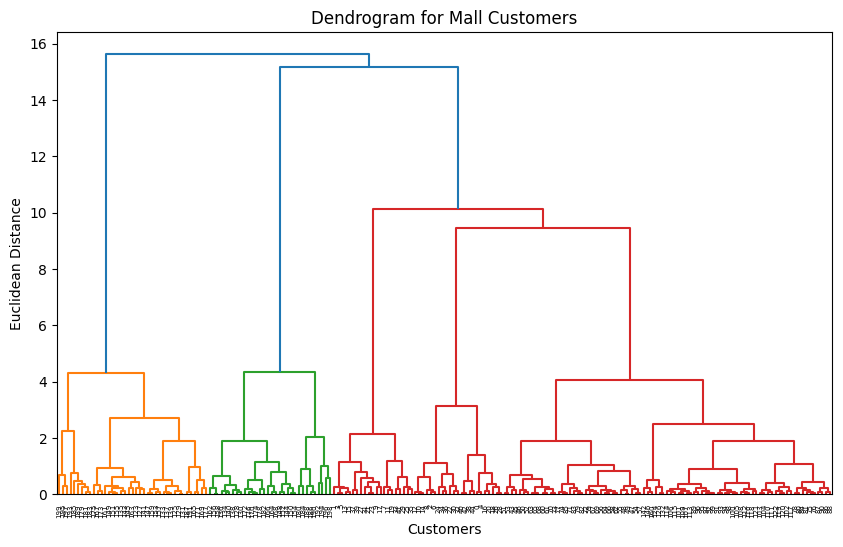

In [34]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 6))
sch.dendrogram(sch.linkage(x_scaled, method='ward'))
plt.title('Dendrogram for Mall Customers')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

In [37]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_pred = hc.fit_predict(x_scaled)

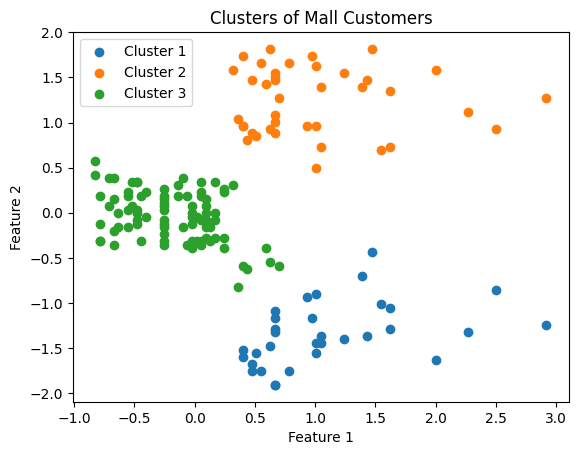

In [38]:
import matplotlib.pyplot as plt
plt.scatter(x_scaled[y_pred == 0, 0], x_scaled[y_pred == 0, 1], label='Cluster 1')
plt.scatter(x_scaled[y_pred == 1, 0], x_scaled[y_pred == 1, 1], label='Cluster 2')
plt.scatter(x_scaled[y_pred == 2, 0], x_scaled[y_pred == 2, 1], label='Cluster 3')

plt.title('Clusters of Mall Customers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.show()